In [2]:
import numpy as np
import plotly.graph_objects as go

In [14]:
def graph_objects(xs, ys, cs):
    fig = go.Figure(data=[go.Scatter3d(x=xs, y=ys, z=cs,
                                       mode='markers', 
                                       marker=dict(
                                       size=12,
                                       color=cs,                # set color to an array/list of desired values
                                       colorscale='Viridis',   # choose a colorscale
                                       opacity=1.0
        ))])
    fig.update_layout(scene = dict(
                        xaxis_title='x',
                        yaxis_title='y',
                        zaxis_title='scaling constant'),
                        margin=dict(r=20, b=10, l=10, t=10))
    fig.show()

In [3]:
parameter_pairs = []
for a in np.linspace(1,10,10):
    for b in np.linspace(1,10,10):
        parameter_pairs.append((a,b))

def beta_skew(a,b):
    return (2*(b-a)*np.sqrt(a+b+1))/((a+b+2)*np.sqrt(a*b))

In [ ]:
parameter_cs = []
for pair in parameter_pairs:
    sample_avg_cs = []
    for sample_params in np.array([200,500,1000,5000]):
        cs = []
        for seed in np.array([2,34,567,2021,0]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],sample_params) 
            test_sample = sample[sample >= np.percentile(sample, 66.7)]
            c = (1-np.max(test_sample)) / np.std(test_sample,ddof=1)
            cs.append(c)
        sample_avg_cs.append(np.average(cs))
    parameter_cs.append(np.average(sample_avg_cs))

In [ ]:
#option 2: depend c values on sample size and skewness rather than alpha and beta
#TODO: This is fucked lol
parameter_cs = []
sample_params = []
for sample_size in np.arange(200,2000,200):
    sample_avg_cs = []
    for pair in parameter_pairs:
        cs = []
        skew = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],sample_size)
            test_sample = sample[sample >= np.percentile(sample, 75)]
            cs.append((1-np.max(test_sample)) / np.std(test_sample,ddof=1))
            skew.append(beta_skew(pair[0],pair[1]))
        parameter_cs.append(np.average(cs))
        sample_params.append((sample_size,np.average(skew)))    

In [8]:
points = {}
for size in [100,200,500,1000,2000,5000]:
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            test_sample = sample[sample >= np.percentile(sample, 75)]
            c = (1-np.max(test_sample)) / np.std(test_sample,ddof=1)
            cs.append(c)
            skew = beta_skew(pair[0],pair[1])
            skews.append(skew)
        if np.average(skews) not in points.keys():
            points[np.average(skews)] = [np.average(cs)]
        else: points[np.average(skews)].append(np.average(cs))

points2 = {}
for k in points.keys():
    points2[k] = np.average(points[k])
print(points2)

{0.0: 1.9305935473185243, 0.565685424949238: 0.32992395662094726, 0.8606629658238705: 0.9593821735916671, 1.0497813183356477: 1.698411357435364, 1.1832159566199232: 2.5825589086101775, 1.2830005981991686: 3.4786153081009625, 1.360672102833218: 4.431272654034536, 1.422952349318048: 5.404441321680598, 1.4740554623801776: 6.4056175701808895, 1.5167701592450753: 7.386732528597083, -0.565685424949238: 0.03788115711953181, 0.28571428571428575: 0.8595939250922501, 0.46770717334674267: 1.3387959748562526, 0.5962847939999439: 2.0361688555672477, 0.692820323027551: 2.74546725136614, 0.768322049753197: 3.4943381142187597, 0.82915619758885: 4.2544403951593255, 0.8793040102298588: 5.0131266275439845, 0.9214008855198341: 5.814325689389918, -0.8606629658238705: 0.038902002088197496, -0.28571428571428575: 0.34194344797127685, 0.1814436846506058: 1.1246624094293385, 0.30983866769659335: 1.7488392701287807, 0.40655781409087094: 2.4266241437506864, 0.4824979096371639: 3.0851289597887344, 0.54392829322042

<Axes: >

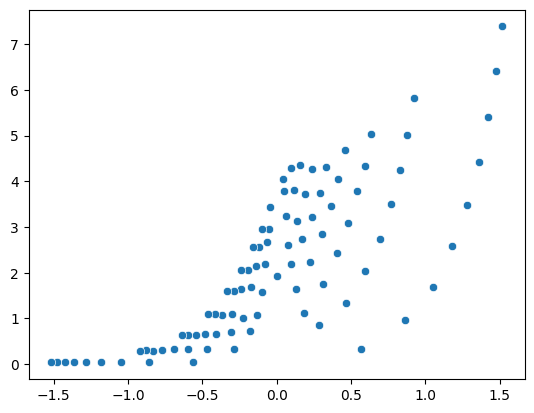

In [7]:
import seaborn as sns
sns.scatterplot(x=points2.keys(),y=points2.values())

In [15]:
points = {}
for size in np.arange(200,5000,200):
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            test_sample = sample[sample >= np.percentile(sample, 75)]
            c = (1-np.max(test_sample)) / np.std(test_sample,ddof=1)
            cs.append(c)
            skew = beta_skew(pair[0],pair[1])
            skews.append(skew)
        if np.average(skews) not in points.keys():
            points[(np.average(skews),size)] = [np.average(cs)]
        else: points[(np.average(skews),size)].append(np.average(cs))

sizes = []
skews = []
cs = []
for k in points.keys():
    sizes.append(k[1])
    skews.append(k[0])
    cs.append(np.average(points[k]))

In [16]:
graph_objects(sizes,skews,cs)

In [17]:
points = {}
for size in np.arange(200,5000,200):
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            test_sample = sample[sample >= np.percentile(sample, 75)]
            c = np.exp(-1*(1-np.max(test_sample)) / np.std(test_sample,ddof=1))
            cs.append(c)
            skew = beta_skew(pair[0],pair[1])
            skews.append(skew)
        if np.average(skews) not in points.keys():
            points[(np.average(skews),size)] = [np.average(cs)]
        else: points[(np.average(skews),size)].append(np.average(cs))

sizes = []
skews = []
cs = []
for k in points.keys():
    sizes.append(k[1])
    skews.append(k[0])
    cs.append(np.average(points[k]))

In [18]:
graph_objects(sizes,skews,cs)

In [ ]:
#option 1: make c a function of Y_n - Y_n-1